# Modelos para el precio de combustibles. 

Se modela el precio promedio del combustible anteriormente analizado (EDA), se sigue la siguiente lógica: cuando se calculan los promedios de cada de cada combustible por separado se tiene una serie de tiempo para cada uno además se puede apreciar la correlación que cada uno presenta, de modo que un modelo predictivo es posible.



In [60]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import normalize
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import time
import datetime

%matplotlib inline
mpl.style.use('ggplot')
#mpl.style.available

In [61]:
promedios = pd.read_csv('promedios_diarios.csv')
promedios.tail(2)

,fecha,Promedio Diésel Automotríz,Promedio Premium,Promedio Regular,Promedio Diésel de Ultra Bajo Azufre (DUBA),Promedio Diésel Agrícola/Marino
364,2024-12-30,25.666764,25.392746,23.971674,25.605823,26.254286
365,2024-12-31,25.675255,25.401801,23.985676,25.618212,26.254286


<AxesSubplot:>

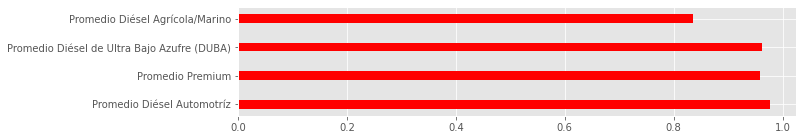

In [62]:
correlation_values = promedios.drop('fecha',axis=1).corr()['Promedio Regular'].drop('Promedio Regular')
correlation_values.plot(kind='barh', figsize=(10, 2),color='red',width=0.3)

Para pronóstico de series de tiempo se debe utilizar un método de validación cruzada distinto, debido a que para entrenar un modelo no se pueden utilizar los valores futuros de la serie. Por lo que se utilizan los valores futuros en el conjunto de prueba y los pasados para el ajuste de multiples árboles de decisión. También es importante mencionar que dentro de estos conjuntos no se elige los datos aleatoriamente. En **scikit-learn** se implementa ese requerimiento por medio de TimeSeriesSplit() que tiene como resultado varios (digamos $n$) conjuntos de índices, correspondientes a los datos que se utilizarán para el modelo. 

1. Para el primer par train-test se utilizan los primeros datos en orden cronológico
2. El segundo segmento tiene un conjunto de ajuste (train) igual al par train-test del segmento anterior.
3. El tercer train es el segundo segmento.
4. Así hasta el segmento $n$.

Lo anterior previene que los conjuntos de prueba en que el modelo no ha sido entrenado puedan ser utilizados para evaluar el modelo y siempre son una partición posterior en la serie de tiempo. Para una mejor claridad de la funcionalidad de TimeSeriesSplit() se imprime la tupla resultante.

In [63]:
y = promedios['Promedio Regular']
X = promedios.drop(['Promedio Regular'],axis=1)
dt = X.pop('fecha')
dt = pd.to_datetime(dt)

TSS = TimeSeriesSplit(n_splits=6)
for train, test in TSS.split(X):
    print("%s %s" % (train[:2], test[:2]))

[0 1] [54 55]
[0 1] [106 107]
[0 1] [158 159]
[0 1] [210 211]
[0 1] [262 263]
[0 1] [314 315]


## 1. Random Forests.

MSE: 0.031957125778274156 R^2: -0.878373874083149 para el segmento 1
MSE: 0.021960295880951504 R^2: -9.600934730784488 para el segmento 2
MSE: 0.08103672984230588 R^2: -1.2160433665686003 para el segmento 3
MSE: 0.012737056924411856 R^2: -1.9404061772689714 para el segmento 4
MSE: 0.0011550136276920232 R^2: 0.5308228555823126 para el segmento 5
MSE: 0.0006458233992793957 R^2: 0.46354362038683283 para el segmento 6
time: 10.546705961227417


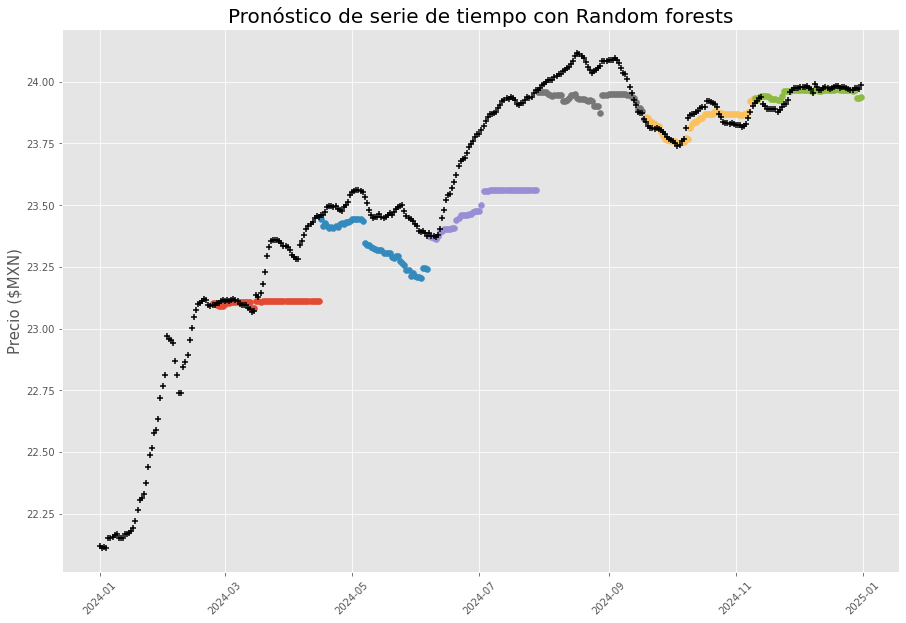

In [67]:
n_estimators=1000
rf = RandomForestRegressor(max_depth=1000,n_estimators=n_estimators, random_state=42)

start_time_rf = time.time()
plt.figure(figsize=(15, 10))
i=1
for train,test in TSS.split(X):
    rf.fit(X.iloc[train], y[train])
    
    y_pred_rf = rf.predict(X.iloc[test])
    
    mse_rf = mean_squared_error(y[test], y_pred_rf)
    r2_rf = r2_score(y[test], y_pred_rf)
    print(f'MSE: {mse_rf} R^2: {r2_rf} para el segmento {i}')
    i = i+1
    
    plt.scatter(x=dt[test],y=y_pred_rf)

plt.scatter(x=dt, y=y,color='k', marker='+')
plt.title("Pronóstico de serie de tiempo con Random forests",fontsize=20)
plt.ylabel('Precio ($MXN)',fontsize=15)
plt.xticks(rotation=45)
plt.grid(True)

end_time_rf = time.time()
rf_train_time = end_time_rf - start_time_rf
print('time:',rf_train_time)


plt.show()

En la mayoría de los segmentos no se obtiene un valor cercano a $R^2 = 1$ y es un valor negativo, quiere decir que el modelo no es un mejor predictor que el promedio de los valores en el conjunto de prueba. Esto sucede porque Random Forests se basa en árboles de decisión para definir una partición del espacio de predictores, y luego promediar el resultado de cada árbol, entonces no hay una extrapolación, dos maneras comúnes de mitigar esta limitación son:

- Aplicar el algoritmo para las diferencias de la serie de tiempo original (precio - precio día anterior).
- Ajustar una dependencia temporal, luego restar los valores ajustados y así aplicar el algoritmo.

In [65]:
#Prepocesamiento del precio, caluclar las diferencias.
y0 = y.iloc[0]
dy = y.diff().dropna()

MSE: 573.5266667731872 R^2: -1.351440556533873 para el segmento 1
MSE: 573.9318796542473 R^2: -1.0638316845155038 para el segmento 2
MSE: 573.3132183406661 R^2: -0.417484472885969 para el segmento 3
MSE: 573.9651505902904 R^2: -1.0585023352680922 para el segmento 4
MSE: 573.8093862966499 R^2: -0.7743918916949555 para el segmento 5
MSE: 573.7820493417873 R^2: -0.9228968374842266 para el segmento 6
time: 10.693006038665771


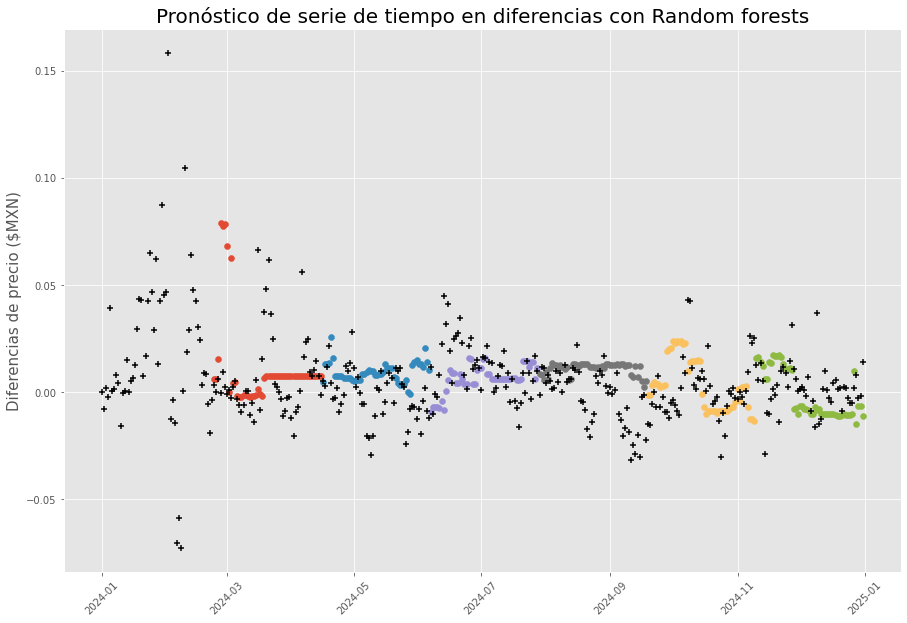

In [69]:
start_time_rf = time.time()
plt.figure(figsize=(15, 10))
i=1
for train,test in TSS.split(X):
    rf.fit(X.iloc[train[1:]], dy[train[1:]])
    
    dy_pred_rf = rf.predict(X.iloc[test])
    
    mse_rf = mean_squared_error(dy[test], y_pred_rf)
    r2_rf = r2_score(dy[test], dy_pred_rf)
    print(f'MSE: {mse_rf} R^2: {r2_rf} para el segmento {i}')
    i = i+1
    
    plt.scatter(x=dt[test],y=dy_pred_rf)

plt.scatter(x=dt, y=np.concatenate(([0],dy)),color='k', marker='+',linewidths=1.5)
plt.title("Pronóstico de serie de tiempo en diferencias con Random forests",fontsize=20)
plt.ylabel('Diferencias de precio ($MXN)',fontsize=15)
plt.xticks(rotation=45)
plt.grid(True)

end_time_rf = time.time()
rf_train_time = end_time_rf - start_time_rf
print('time:',rf_train_time)


plt.show()

La conclusión al ver ambas figuras es que ambos modelos no son adecuados para estos datos, aunque hay evidencias de que el modelo funciona de manera limitada (los últimos segmentos del primer modelo), puede haber una importante causa: el conjunto de datos tiene 365 observaciones, lo cual deriva en dos limitaciones:

- Al ser sólo de 2024, los datos no tienen una estacionalidad (seasonality) que se pueda explotar.
- En general, la complejidad de los modelos implica un requerimiento más alto de observaciones.